In [1]:
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import time
import sklearn
import sklearn.datasets
import sklearn.linear_model
import matplotlib
from matplotlib import cm

%matplotlib inline 
matplotlib.rcParams['figure.figsize'] = (8.0, 4.0)

x = np.array([1.0, 2.0, 3.0]) 
print(x)

# Single Instruction Multiple Data (SIMD)
x + 3.0

[1. 2. 3.]


array([4., 5., 6.])

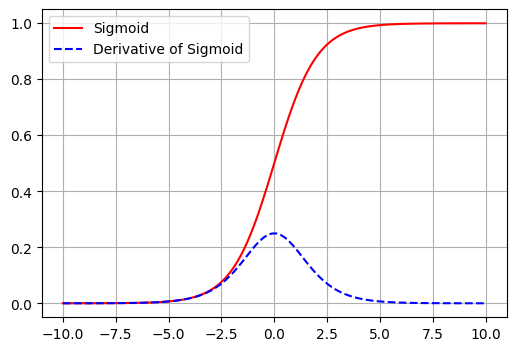

In [2]:
def sigmoid(z):
    return 1. / (1 + np.exp(-z))

def dsigmoid(z):
    s = sigmoid(z)
    return s * (1 - s)

z = np.linspace(-10, 10, num=100)
g = sigmoid(z)
dg = dsigmoid(z)
plt.figure(figsize=(6, 4))
plt.plot(z, g, 'r')
plt.plot(z, dg, 'b--')
plt.legend(['Sigmoid', 'Derivative of Sigmoid'])
plt.grid()
plt.show()

In [3]:
inp = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
print("sigmoid(inp) = ", sigmoid(inp))
print("dsigmoid(inp) = ", dsigmoid(inp))

sigmoid(inp) =  [0.04742587 0.26894142 0.5        0.73105858 0.95257413]
dsigmoid(inp) =  [0.04517666 0.19661193 0.25       0.19661193 0.04517666]


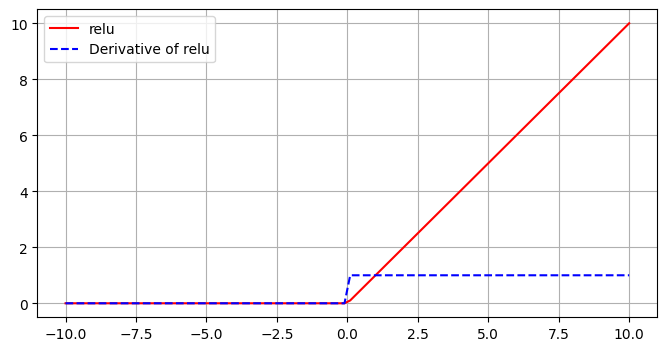

In [4]:
def relu(z):
    return np.maximum(z, 0)

def drelu(z):
    return (z > 0)

z = np.linspace(-10, 10, num=100)
g = relu(z)
dg = drelu(z)
plt.plot(z, g,'r')
plt.plot(z, dg, 'b--')
plt.legend(['relu','Derivative of relu'])
plt.grid()
plt.show()

In [5]:
#PyTorch Example of AutoGrad
import torch
print(torch.__version__)
w1 = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0]], requires_grad=True)
w2 = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0]], requires_grad=True)
out = (w1 ** 2 + w2 ** 3) .sum()
out.backward()
print(out)
print(w1.grad)  # 2 * w1
print(w2.grad)  # 3 * w2 ** 2

2.10.0+cpu
tensor(280., grad_fn=<SumBackward0>)
tensor([[ 0.,  2.,  4.],
        [ 6.,  8., 10.]])
tensor([[ 0.,  3., 12.],
        [27., 48., 75.]])


In [6]:
def learning_rate_effect(gamma = 0.15):
    X1 = np.arange(-1, 1, 0.001)
    X2 = np.arange(-1, 1, 0.001)
    X1, X2 = np.meshgrid(X1, X2)
    A = np.sin((0.5 * X1**2) - (0.25 * X2**2) + 3)
    B = np.cos((2 * X1) + 1 - (np.e**X2))
    Z = -A * B
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes (projection='3d')
    plt.title("Learning Rate %s" % gamma)
    #Plot the surface.
    surf = ax.plot_surface(X1, X2, Z, cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.75)
    
    #Customize the z axis.
    ax.set_zlim(-0.5, 0.5)
    #Do simple gradient descent and plot
    x1 = -0.5
    x2 = 0.1
    for i in range(30):
        z=-np.sin((.5*x1**2)-(.25*x2**2)+3)*np.cos((2*x1) + 1 -(np.e**x2)) 
        if not (x1>1 or x1 < - 1 or x2 > 1 or x2 < - 1 ) : 
            ax.scatter(x1,x2,z,c='r', marker='$'+str(i)+'$', s = 50 )
        #Partial derivatives with respect to x and y (just trust me)
        dx1=(2*np.sin(2*x1-np.e**x2+1)*np.sin(.5*x1**2-.25*x2**2+3)-x1*np.cos(2*x1-np.e**x2+1)*np.cos(.5*x1**2-.25*x2**2+3)) 
        dx2=(.5*(x2*np.cos(.25*x2**2-.5*x1**2-3)*np.cos(np.e**x2-2*x1-1)) -np.e**x2*np.sin(.25*x2**2-.5*x1**2-3)*np.sin(np.e**x2-2*x1-1))
        x1=x1-gamma*dx1
        x2=x2-gamma*dx2
    _ = ax.set_xlabel('x')
    _ = ax.set_ylabel('y')
    _ = ax.set_zlabel('Cost (2)')

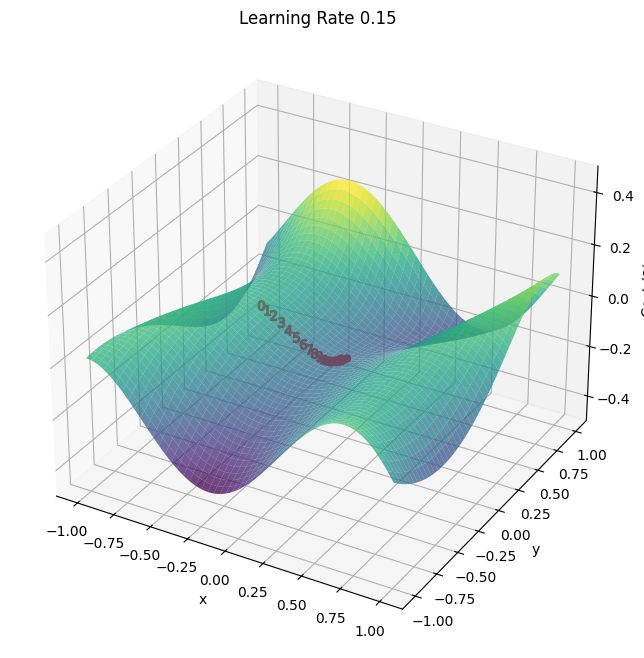

In [7]:
learning_rate_effect(0.15)

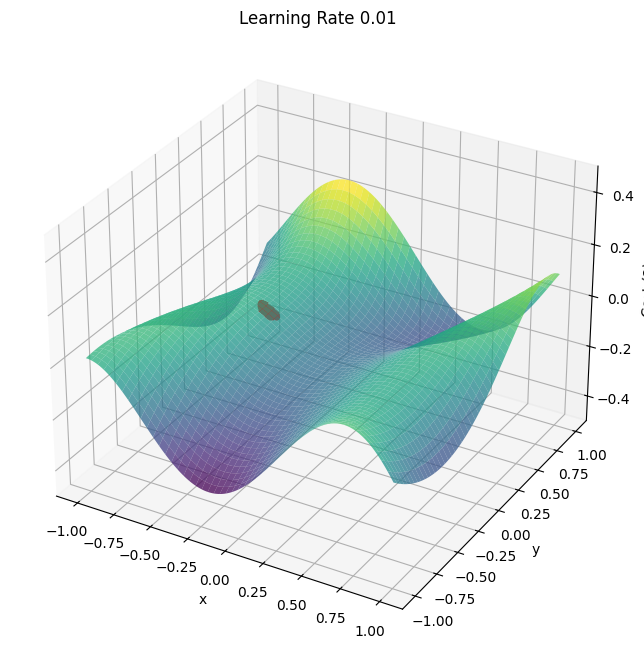

In [8]:
learning_rate_effect(0.01)

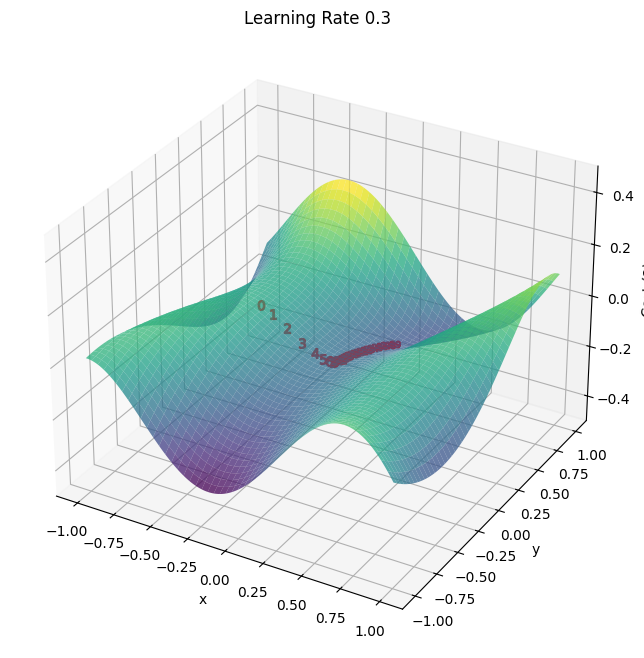

In [9]:
learning_rate_effect(0.3)